# Analyze results from phyloglm

In [25]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt

# Resolve repo root whether cwd is repo root, scripts/, or a stage subdirectory.
cwd = os.getcwd()
if os.path.basename(cwd) == "orb-selection":
    repo_root = cwd
elif os.path.basename(os.path.dirname(cwd)) == "orb-selection":
    repo_root = os.path.dirname(cwd)
elif os.path.basename(os.path.dirname(os.path.dirname(cwd))) == "orb-selection":
    repo_root = os.path.dirname(os.path.dirname(cwd))
else:
    repo_root = cwd

src_path = os.path.join(repo_root, "src")
stage04_path = os.path.join(repo_root, "scripts", "04_permulation_loss_dup")
for path in (src_path, stage04_path):
    if path not in sys.path:
        sys.path.insert(0, path)

results_path = os.path.join(repo_root, "results")

print(f"Using src path: {src_path}")
print(f"Using stage-04 path: {stage04_path}")

# Import modules
import odds_ratio_test as ort
from id_converter import convert_hogs_to_locs

%load_ext autoreload

Using src path: /Users/calvin/orb-selection/src
Using stage-04 path: /Users/calvin/orb-selection/scripts/04_permulation_loss_dup
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
loss_df = pd.read_csv(f"{results_path}/phyloglm_loss_qvals.csv")
dup_df = pd.read_csv(f"{results_path}/phyloglm_dup_qvals.csv")

In [16]:
loss_df[loss_df["qvalue"] < 0.05].sort_values("qvalue")

,HOG,error,fit,coef_.Intercept._Estimate,coef_.Intercept._StdErr,coef_.Intercept._z.value,coef_.Intercept._p.value,coef_orb_weavingTRUE_Estimate,coef_orb_weavingTRUE_StdErr,coef_orb_weavingTRUE_z.value,coef_orb_weavingTRUE_p.value,logLik,qvalue
6370,N5.HOG0054404,NaN,NaN,-0.969706,0.538269,-1.801526,0.071620,2.270508,0.417346,5.440353,5.317511e-08,NaN,0.000252
5256,N5.HOG0048549,NaN,NaN,-1.773049,0.493068,-3.595950,0.000323,1.953208,0.359585,5.431833,5.577798e-08,NaN,0.000252
602,N5.HOG0012007,NaN,NaN,0.117112,0.172988,0.676997,0.498408,-1.175099,0.227307,-5.169665,2.345141e-07,NaN,0.000705
6582,N5.HOG0055339,NaN,NaN,0.033977,0.183415,0.185247,0.853035,-1.305802,0.262347,-4.977381,6.445032e-07,NaN,0.001453
12056,N5.HOG0073251,NaN,NaN,0.257579,0.187771,1.371768,0.170136,-1.174331,0.246609,-4.761912,1.917669e-06,NaN,0.002162
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11845,N5.HOG0072099,NaN,NaN,-0.019617,0.234601,-0.083619,0.933360,-0.674286,0.224937,-2.997658,2.720626e-03,NaN,0.049266
1403,N5.HOG0020612,NaN,NaN,-0.817271,0.404281,-2.021540,0.043224,0.759124,0.253455,2.995104,2.743514e-03,NaN,0.049439
994,N5.HOG0016545,NaN,NaN,0.022423,0.199926,0.112154,0.910701,-0.527480,0.176076,-2.995756,2.737652e-03,NaN,0.049439
3100,N5.HOG0034163,NaN,NaN,-0.121531,0.277194,-0.438434,0.661071,-0.934782,0.312139,-2.994762,2.746593e-03,NaN,0.049439


In [18]:
dup_df[dup_df["qvalue"] < 0.05].sort_values("qvalue").shape[0]

23

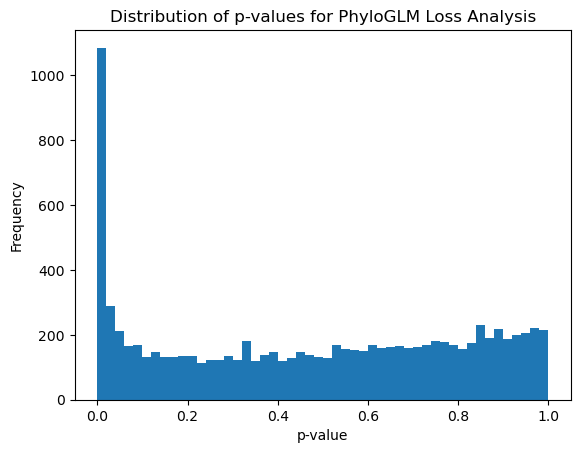

In [22]:
plt.hist(loss_df["coef_orb_weavingTRUE_p.value"], bins=50)
plt.title("Distribution of p-values for PhyloGLM Loss Analysis")
plt.xlabel("p-value")
plt.ylabel("Frequency")
plt.show()

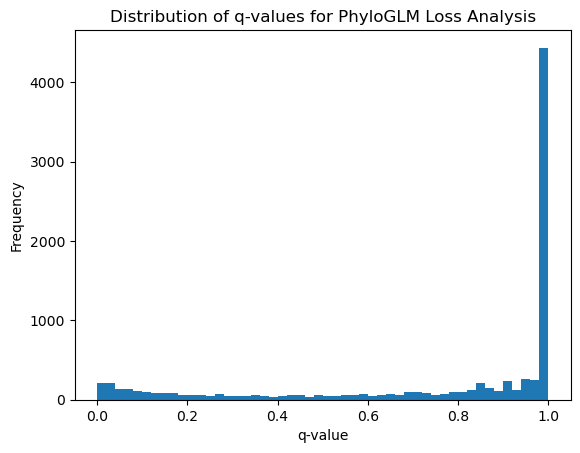

In [24]:
plt.hist(loss_df["qvalue"], bins=50)
plt.title("Distribution of q-values for PhyloGLM Loss Analysis")
plt.xlabel("q-value")
plt.ylabel("Frequency")
plt.show()

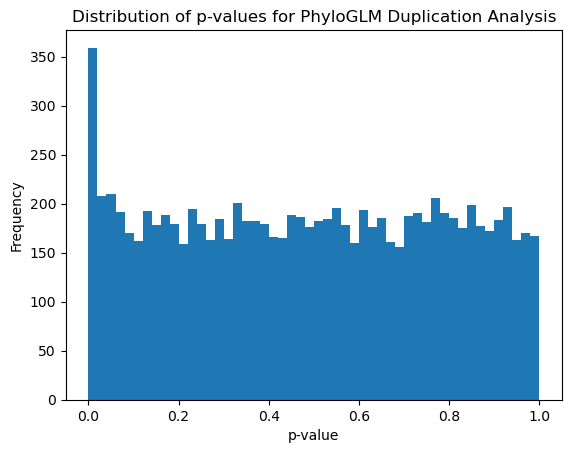

In [23]:
plt.hist(dup_df["coef_orb_weavingTRUE_p.value"], bins=50)
plt.title("Distribution of p-values for PhyloGLM Duplication Analysis")
plt.xlabel("p-value")
plt.ylabel("Frequency")
plt.show()

In [ ]:
%autoreload 2
results_all = ort.PermulationTestResults.load_from_pickle("results/odds_ratio_test/Results_Apr16/Run1_occ_30-88_10000x_all_orb/results.pkl")
_, counts1, run1_df, total_count1 = results_all.filter_for_permulation_hits()
run1_df[run1_df["Significant by permulation"].str.contains("loss", na=False)].sort_values("p-value")

AttributeError: 'Series' object has no attribute 'contains'

In [28]:
run1_df[run1_df["Significant by avgd thresholds"] != ""]

,Occupancy,Log odds ratio of loss,Log odds ratio of duplication,P-value loss more likely in fg,P-value loss more likely in bg,P-value duplication more likely in fg,P-value duplication more likely in bg,Significant by avgd thresholds,Significant by permulation
HOG,,,,,,,,,
N5.HOG0001627,33,2.048042501668181,-4.020456662035705,0.0449,0.9551,0.9745,0.0253,dup_bg,"loss_fg, dup_bg"
N5.HOG0002031,46,-3.8236010086737187,1.8546381292872387,0.9996,0.0004,0.3311,0.6686,loss_bg,loss_bg
N5.HOG0002072,52,3.473732866474442,-0.7627257209774443,0.0108,0.9892,0.7989,0.2011,loss_fg,loss_fg
N5.HOG0002078,42,-4.64814905627464,3.9760809321303596,0.9519,0.0481,0.0005,0.9995,"loss_bg, dup_fg","loss_bg, dup_fg"
N5.HOG0002348,65,-2.0357916420203486,2.270862603128372,0.8725,0.1275,0.0455,0.9545,dup_fg,dup_fg
...,...,...,...,...,...,...,...,...,...
N5.HOG0072918,33,-5.693836317970543,2.6592090830543094,1.0,0.0,0.0538,0.9462,loss_bg,loss_bg
N5.HOG0072996,32,-0.6826733991242648,2.239125359489152,0.8689,0.1311,0.0292,0.9708,dup_fg,dup_fg
N5.HOG0073071,35,-2.6510150184411816,2.2639256052709866,0.8765,0.1235,0.0175,0.9825,dup_fg,dup_fg
